In [ ]:
!pip install transformers datasets torch evaluate scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
dataset = load_dataset("stanfordnlp/imdb")

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
# Convertimos el dataset a tabla
df = pd.DataFrame(dataset["test"])

df.head()

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0


In [ ]:
# Agregamos una columna con el nombre de la etiqueta
df["sentimiento_real"] = df["label"].map({
    0: "Negativo",
    1: "Positivo"
})

df.head()

,text,label,sentimiento_real
0,I love sci-fi and am willing to put up with a ...,0,Negativo
1,"Worth the entertainment value of a rental, esp...",0,Negativo
2,its a totally average film with a few semi-alr...,0,Negativo
3,STAR RATING: ***** Saturday Night **** Friday ...,0,Negativo
4,"First off let me say, If you haven't enjoyed a...",0,Negativo


In [ ]:
# Se toma una muestra
df_neg = df[df["label"] == 0].sample(500, random_state=123)
df_pos = df[df["label"] == 1].sample(500, random_state=123)

df_muestra = pd.concat([df_neg, df_pos])
df_muestra = df_muestra.sample(frac=1, random_state=123).reset_index(drop=True)

df_muestra.head()

,text,label,sentimiento_real
0,I have just wasted my Saturday night watching ...,0,Negativo
1,"Dante would of been mortified, if he knew that...",0,Negativo
2,Would it be too trite of me to create a review...,0,Negativo
3,I saw this film on 19SEP2009 at the Cambridge ...,1,Positivo
4,I agree that this movie is about sex without a...,0,Negativo


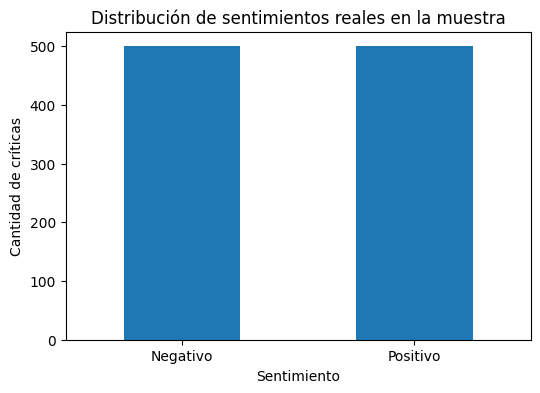

In [ ]:
conteo_sentimientos = df_muestra["sentimiento_real"].value_counts()

plt.figure(figsize=(6,4))
conteo_sentimientos.plot(kind="bar")
plt.title("Distribución de sentimientos reales en la muestra")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de críticas")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Analizamos la longitud de las reseñas
df_muestra["num_palabras"] = df_muestra["text"].apply(lambda x: len(x.split()))
df_muestra["num_caracteres"] = df_muestra["text"].apply(len)

df_muestra[["num_palabras", "num_caracteres"]].describe()

,num_palabras,num_caracteres
count,1000.000000,1000.000000
mean,222.530000,1258.496000
std,161.409442,923.737223
min,8.000000,61.000000
25%,125.000000,693.000000
50%,170.000000,951.500000
75%,267.000000,1509.750000
max,1002.000000,5765.000000


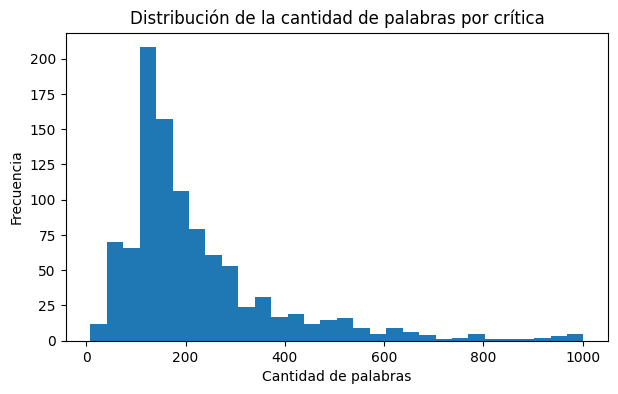

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df_muestra["num_palabras"], bins=30)
plt.title("Distribución de la cantidad de palabras por crítica")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Cargar el modelo transformer
device = 0 if torch.cuda.is_available() else -1

modelo_sentimiento = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
# Probar el modelo con una crítica
texto_prueba = df_muestra.loc[0, "text"]

modelo_sentimiento(texto_prueba[:512])

[{'label': 'NEGATIVE', 'score': 0.9957206845283508}]

In [ ]:
# Aplicar el modelo a todas las críticas
predicciones = modelo_sentimiento(
    df_muestra["text"].tolist(),
    batch_size=16,
    truncation=True,
    max_length=512
)

predicciones[:5]

[{'label': 'NEGATIVE', 'score': 0.9963686466217041},
 {'label': 'NEGATIVE', 'score': 0.9998024106025696},
 {'label': 'NEGATIVE', 'score': 0.9996654987335205},
 {'label': 'POSITIVE', 'score': 0.8992779850959778},
 {'label': 'POSITIVE', 'score': 0.9658159613609314}]

In [ ]:
# Guardar las predicciones
df_muestra["prediccion_modelo"] = [p["label"] for p in predicciones]
df_muestra["confianza_modelo"] = [p["score"] for p in predicciones]

df_muestra.head()

,text,label,sentimiento_real,num_palabras,num_caracteres,prediccion_modelo,confianza_modelo
0,I have just wasted my Saturday night watching ...,0,Negativo,142,822,NEGATIVE,0.996369
1,"Dante would of been mortified, if he knew that...",0,Negativo,131,700,NEGATIVE,0.999802
2,Would it be too trite of me to create a review...,0,Negativo,297,1649,NEGATIVE,0.999665
3,I saw this film on 19SEP2009 at the Cambridge ...,1,Positivo,273,1581,POSITIVE,0.899278
4,I agree that this movie is about sex without a...,0,Negativo,148,865,POSITIVE,0.965816


In [ ]:
# Se convierte a 0 y 1

df_muestra["prediccion_num"] = df_muestra["prediccion_modelo"].map({
    "NEGATIVE": 0,
    "POSITIVE": 1
})

df_muestra["sentimiento_predicho"] = df_muestra["prediccion_num"].map({
    0: "Negativo",
    1: "Positivo"
})

df_muestra.head()

,text,label,sentimiento_real,num_palabras,num_caracteres,prediccion_modelo,confianza_modelo,prediccion_num,sentimiento_predicho
0,I have just wasted my Saturday night watching ...,0,Negativo,142,822,NEGATIVE,0.996369,0,Negativo
1,"Dante would of been mortified, if he knew that...",0,Negativo,131,700,NEGATIVE,0.999802,0,Negativo
2,Would it be too trite of me to create a review...,0,Negativo,297,1649,NEGATIVE,0.999665,0,Negativo
3,I saw this film on 19SEP2009 at the Cambridge ...,1,Positivo,273,1581,POSITIVE,0.899278,1,Positivo
4,I agree that this movie is about sex without a...,0,Negativo,148,865,POSITIVE,0.965816,1,Positivo


In [ ]:
# Metricas del modelo
y_real = df_muestra["label"]
y_pred = df_muestra["prediccion_num"]

accuracy = accuracy_score(y_real, y_pred)
precision = precision_score(y_real, y_pred)
recall = recall_score(y_real, y_pred)
f1 = f1_score(y_real, y_pred)

metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [accuracy, precision, recall, f1]
})

metricas

,Métrica,Valor
0,Accuracy,0.900000
1,Precision,0.921941
2,Recall,0.874000
3,F1-score,0.897331


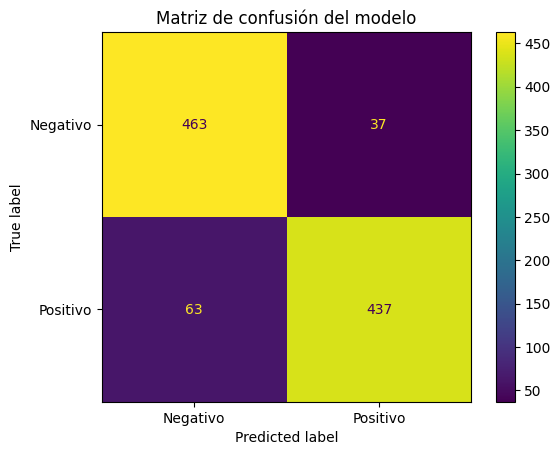

In [ ]:
# Matriz de confusion
cm = confusion_matrix(y_real, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativo", "Positivo"]
)

disp.plot()
plt.title("Matriz de confusión del modelo")
plt.show()

In [ ]:
print(classification_report(
    y_real,
    y_pred,
    target_names=["Negativo", "Positivo"]
))

              precision    recall  f1-score   support

    Negativo       0.88      0.93      0.90       500
    Positivo       0.92      0.87      0.90       500

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



In [ ]:
# Errores del modelo
errores = df_muestra[df_muestra["label"] != df_muestra["prediccion_num"]]

errores[["text", "sentimiento_real", "sentimiento_predicho", "confianza_modelo"]].head(10)

,text,sentimiento_real,sentimiento_predicho,confianza_modelo
4,I agree that this movie is about sex without a...,Negativo,Positivo,0.965816
23,"Let's not beat about the bush here, Taylor Hac...",Positivo,Negativo,0.970311
28,"Dude, I thought this movie rocked. Perfect for...",Positivo,Negativo,0.952877
36,"I caught this film -- under the title of ""What...",Negativo,Positivo,0.996707
39,Graphics is far from the best part of the game...,Positivo,Negativo,0.974262
44,"This movie was very good, not great but very g...",Positivo,Negativo,0.797934
48,The filmmakers apparently had enough money to ...,Negativo,Positivo,0.942509
52,"One of the classic low budget 70's movies, thi...",Positivo,Negativo,0.999080
70,Poor Bela Lugosi. Just another day at work. A ...,Negativo,Positivo,0.990237
80,"Someone told me that Pink Flamingos was, in a ...",Negativo,Positivo,0.627598


In [ ]:
# Ejemplo de algún error
print(errores.iloc[0]["text"])
print("Real:", errores.iloc[0]["sentimiento_real"])
print("Predicho:", errores.iloc[0]["sentimiento_predicho"])
print("Confianza:", errores.iloc[0]["confianza_modelo"])

I agree that this movie is about sex without any seduction or love. In fact, it makes sex seem so boring and makes me wonder why bother. I actually don't think at all this remotely speaks of how Canadian Indian second generations feel about sex. At any rate, did you know the first hotel/drunk idea was copied from a Korean movie, Yopgijogin gunyo, made in 2001 or thereabouts? That Korean film was actually brilliant as comedy but at the same time compels the audience to reflect on the complexity of man-woman relationships and man-woman difference in experience and thinking. I mean most of the Neal N Nikki hotel/drunk segment was emulated take by take. Can't Bollywood movie makers try to make originals only, please? Seriously, I never enjoyed a Hindi flick that is a copycat. The ones I enjoy have always spoken Indian feelings through Indian cultural means.
Real: Negativo
Predicho: Positivo
Confianza: 0.9658159613609314
